# Full Pipeline 03: Evaluation and Backtest

This notebook evaluates the canonical DQN policy against the reusable `evaluation/` framework.

Inputs:

- `output/full_pipeline/model_state_weekly_hmm_news.csv`
- `output/full_pipeline/rl_validation_actions.csv`
- `output/full_pipeline/rl_locked_test_actions.csv`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "evaluation").exists() and (candidate / "full_pipeline").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from evaluation import (
    BacktestEngine,
    EvaluationConfig,
    all_baseline_policies,
    bootstrap_metric_table,
    default_action_space,
    load_default_dataset,
    plot_equity_curves,
    summary_table,
)
from _pipeline_utils import OUTPUT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)


In [ ]:
state_path = OUTPUT_DIR / "model_state_weekly_hmm_news.csv"

# Prefer finetuned canonical files if present; otherwise use standard canonical names.
validation_actions_path = OUTPUT_DIR / "rl_validation_actions.csv"
locked_test_actions_path = OUTPUT_DIR / "rl_locked_test_actions.csv"
if (OUTPUT_DIR / "rl_validation_actions_finetuned.csv").exists():
    validation_actions_path = OUTPUT_DIR / "rl_validation_actions_finetuned.csv"
if (OUTPUT_DIR / "rl_locked_test_actions_finetuned.csv").exists():
    locked_test_actions_path = OUTPUT_DIR / "rl_locked_test_actions_finetuned.csv"

dataset = load_default_dataset(state_path)
action_space = default_action_space()
engine = BacktestEngine(
    dataset=dataset,
    action_space=action_space,
    config=EvaluationConfig(transaction_cost=0.001, risk_penalty=0.05, risk_window=12),
)

display(dataset.describe_splits())
display(dataset.describe_feature_blocks())
print("Validation actions file:", validation_actions_path.relative_to(REPO_ROOT))
print("Locked-test actions file:", locked_test_actions_path.relative_to(REPO_ROOT))

,split,rows,start,end
0,warmup,14,2014-03-28,2014-06-27
1,train,339,2014-07-04,2020-12-25
2,validation,105,2021-01-01,2022-12-30
3,locked_test,167,2023-01-06,2026-03-13


,block,n_columns,example_columns
0,price,35,"spy_ret_1d, spy_ret_5d, spy_ret_20d, spy_vol_5..."
1,macro,31,"bamlh0a0hym2_level, bamlh0a0hym2_chg_5d, cfnai..."
2,regime,4,"regime_filtered, regime_viterbi, filtered_prob..."
3,text,5,"news_finbert_compound_spy, news_finbert_compou..."


## Baseline Benchmarks

The baselines run on the same merged state table and consume the full block set:

- price
- macro
- regime
- text


In [3]:
include_blocks = ("price", "macro", "regime", "text")
baselines = all_baseline_policies(action_space)

validation_results = engine.run_many(baselines, split="validation", include_blocks=include_blocks)
locked_test_results = engine.run_many(baselines, split="locked_test", include_blocks=include_blocks)

print("Validation summary")
display(summary_table(validation_results))
print("Locked-test summary")
display(summary_table(locked_test_results))


Validation summary


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,105.0,0.018391,0.009066,0.001812,4.982270,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000172
1,spy_only,105.0,0.067832,0.033037,0.184064,0.268378,0.468450,-0.239272,0.138072,0.009524,0.0010,0.514286,-0.000206
2,momentum_rotation_20d,105.0,0.010368,0.005121,0.132257,0.104621,0.164405,-0.161091,0.031792,0.409524,0.0430,0.552381,-0.000543
3,spy_80_tlt_20,105.0,-0.011772,-0.005848,0.152120,0.037388,0.063366,-0.252807,-0.023130,0.009524,0.0010,0.514286,-0.000815
4,gld_only,105.0,-0.027073,-0.013500,0.133363,-0.034920,-0.051379,-0.173483,-0.077820,0.009524,0.0010,0.533333,-0.000950
5,balanced_60_30_10,105.0,-0.057889,-0.029100,0.126170,-0.170990,-0.288991,-0.247677,-0.117494,0.009524,0.0010,0.523810,-0.001160
6,heuristic_regime_proxy,105.0,-0.105252,-0.053588,0.137587,-0.331424,-0.590688,-0.252506,-0.212223,0.186667,0.0196,0.504762,-0.001642
7,equal_weight_spy_tlt_gld,105.0,-0.090055,-0.045661,0.102505,-0.404583,-0.723780,-0.221510,-0.206135,0.009524,0.0010,0.533333,-0.001401
8,defensive_20_60_20,105.0,-0.180898,-0.094097,0.111258,-0.831821,-1.384266,-0.284818,-0.330375,0.009524,0.0010,0.447619,-0.002410
9,tlt_only,105.0,-0.307662,-0.166474,0.158525,-1.067074,-1.699467,-0.391149,-0.425602,0.009524,0.0010,0.447619,-0.004178


Locked-test summary


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,167.0,0.163555,0.048298,0.000787,59.983868,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000907
1,gld_only,167.0,1.377401,0.309513,0.171184,1.664837,2.498113,-0.145468,2.127708,0.005988,0.0010,0.586826,0.004476
2,equal_weight_spy_tlt_gld,167.0,0.598671,0.157300,0.096691,1.561292,2.707431,-0.092219,1.705727,0.005988,0.0010,0.574850,0.002301
3,balanced_60_30_10,167.0,0.510345,0.136999,0.102350,1.307084,2.288772,-0.100816,1.358911,0.005988,0.0010,0.580838,0.001914
4,spy_only,167.0,0.741621,0.188577,0.141179,1.296514,1.855163,-0.168772,1.117353,0.005988,0.0010,0.574850,0.002633
5,spy_80_tlt_20,167.0,0.548197,0.145797,0.119400,1.201034,1.909304,-0.131781,1.106355,0.005988,0.0010,0.562874,0.001995
6,momentum_rotation_20d,167.0,0.700984,0.179872,0.156569,1.136594,1.523746,-0.148595,1.210486,0.317365,0.0530,0.592814,0.002526
7,defensive_20_60_20,167.0,0.289940,0.082502,0.101908,0.829378,1.487001,-0.134524,0.613290,0.005988,0.0010,0.544910,0.000984
8,heuristic_regime_proxy,167.0,0.232153,0.067163,0.113768,0.629576,0.764472,-0.147037,0.456780,0.232934,0.0389,0.574850,0.000736
9,tlt_only,167.0,-0.076144,-0.024359,0.137876,-0.109841,-0.174408,-0.220038,-0.110704,0.005988,0.0010,0.491018,-0.001170


In [ ]:
validation_actions = pd.read_csv(validation_actions_path, parse_dates=["week_end"])
locked_test_actions = pd.read_csv(locked_test_actions_path, parse_dates=["week_end"])

validation_target = dataset.subset("validation").frame
locked_test_target = dataset.subset("locked_test").frame

assert len(validation_actions) == len(validation_target), "Validation action count does not match split length."
assert len(locked_test_actions) == len(locked_test_target), "Locked-test action count does not match split length."

rl_label = "rl_finetuned_best" if "finetuned" in validation_actions_path.name else "dqn_hmm_news"

rl_validation = engine.evaluate_precomputed_actions(
    action_ids=validation_actions["action_id"],
    split="validation",
    include_blocks=include_blocks,
    name=rl_label,
)
rl_locked_test = engine.evaluate_precomputed_actions(
    action_ids=locked_test_actions["action_id"],
    split="locked_test",
    include_blocks=include_blocks,
    name=rl_label,
)

combined_validation = summary_table(validation_results + [rl_validation])
combined_locked_test = summary_table(locked_test_results + [rl_locked_test])

print("Validation summary with RL")
display(combined_validation)
print("Locked-test summary with RL")
display(combined_locked_test)

Validation summary with RL


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,105.0,0.018391,0.009066,0.001812,4.982270,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000172
1,spy_only,105.0,0.067832,0.033037,0.184064,0.268378,0.468450,-0.239272,0.138072,0.009524,0.0010,0.514286,-0.000206
2,momentum_rotation_20d,105.0,0.010368,0.005121,0.132257,0.104621,0.164405,-0.161091,0.031792,0.409524,0.0430,0.552381,-0.000543
3,spy_80_tlt_20,105.0,-0.011772,-0.005848,0.152120,0.037388,0.063366,-0.252807,-0.023130,0.009524,0.0010,0.514286,-0.000815
4,gld_only,105.0,-0.027073,-0.013500,0.133363,-0.034920,-0.051379,-0.173483,-0.077820,0.009524,0.0010,0.533333,-0.000950
5,balanced_60_30_10,105.0,-0.057889,-0.029100,0.126170,-0.170990,-0.288991,-0.247677,-0.117494,0.009524,0.0010,0.523810,-0.001160
6,heuristic_regime_proxy,105.0,-0.105252,-0.053588,0.137587,-0.331424,-0.590688,-0.252506,-0.212223,0.186667,0.0196,0.504762,-0.001642
7,equal_weight_spy_tlt_gld,105.0,-0.090055,-0.045661,0.102505,-0.404583,-0.723780,-0.221510,-0.206135,0.009524,0.0010,0.533333,-0.001401
8,dqn_hmm_news,105.0,-0.144475,-0.074366,0.144433,-0.462263,-0.664320,-0.198826,-0.374028,0.521905,0.0548,0.485714,-0.002229
9,defensive_20_60_20,105.0,-0.180898,-0.094097,0.111258,-0.831821,-1.384266,-0.284818,-0.330375,0.009524,0.0010,0.447619,-0.002410


Locked-test summary with RL


,strategy,weeks,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,average_turnover,total_transaction_cost,win_rate,mean_reward
0,cash_only,167.0,0.163555,0.048298,0.000787,59.983868,NaN,0.000000,NaN,0.000000,0.0000,1.000000,0.000907
1,gld_only,167.0,1.377401,0.309513,0.171184,1.664837,2.498113,-0.145468,2.127708,0.005988,0.0010,0.586826,0.004476
2,equal_weight_spy_tlt_gld,167.0,0.598671,0.157300,0.096691,1.561292,2.707431,-0.092219,1.705727,0.005988,0.0010,0.574850,0.002301
3,balanced_60_30_10,167.0,0.510345,0.136999,0.102350,1.307084,2.288772,-0.100816,1.358911,0.005988,0.0010,0.580838,0.001914
4,spy_only,167.0,0.741621,0.188577,0.141179,1.296514,1.855163,-0.168772,1.117353,0.005988,0.0010,0.574850,0.002633
5,spy_80_tlt_20,167.0,0.548197,0.145797,0.119400,1.201034,1.909304,-0.131781,1.106355,0.005988,0.0010,0.562874,0.001995
6,momentum_rotation_20d,167.0,0.700984,0.179872,0.156569,1.136594,1.523746,-0.148595,1.210486,0.317365,0.0530,0.592814,0.002526
7,dqn_hmm_news,167.0,0.318948,0.090024,0.083514,1.074452,1.458768,-0.048189,1.868131,0.528144,0.0882,0.640719,0.001214
8,defensive_20_60_20,167.0,0.289940,0.082502,0.101908,0.829378,1.487001,-0.134524,0.613290,0.005988,0.0010,0.544910,0.000984
9,heuristic_regime_proxy,167.0,0.232153,0.067163,0.113768,0.629576,0.764472,-0.147037,0.456780,0.232934,0.0389,0.574850,0.000736


In [5]:
bootstrap_metric_table(locked_test_results + [rl_locked_test], metric="sharpe_ratio", n_boot=300, seed=7)


,strategy,sharpe_ratio_ci_low,sharpe_ratio_ci_high
0,cash_only,56.058890,65.064479
1,spy_only,0.189675,2.554732
2,tlt_only,-1.140880,0.958184
3,gld_only,0.554777,3.040424
4,spy_80_tlt_20,0.145479,2.448081
5,balanced_60_30_10,0.259623,2.545744
6,defensive_20_60_20,-0.092637,2.033621
7,equal_weight_spy_tlt_gld,0.621584,2.830327
8,momentum_rotation_20d,0.086392,2.444338
9,heuristic_regime_proxy,-0.404168,2.045210


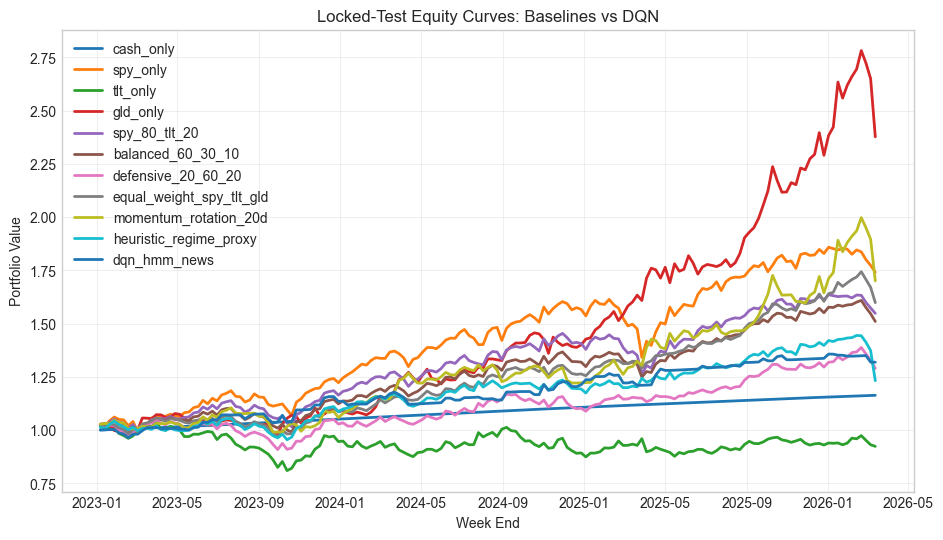

In [ ]:
plot_equity_curves(locked_test_results + [rl_locked_test], title="Locked-Test Equity Curves: Baselines vs RL")
plt.show()

# Focused comparison: normal portfolio (equal-weight) vs RL.
normal_name = "equal_weight_spy_tlt_gld"
focused = [result for result in locked_test_results if result.name == normal_name] + [rl_locked_test]

if len(focused) >= 2:
    plot_equity_curves(focused, title="Locked-Test: RL vs Normal Portfolio (Equal Weight)")
    plt.show()
else:
    print(f"Normal portfolio baseline '{normal_name}' not found in locked_test_results.")

In [7]:
action_mix = pd.DataFrame(
    {
        "validation": validation_actions["action_name"].value_counts(),
        "locked_test": locked_test_actions["action_name"].value_counts(),
    }
).fillna(0).astype(int)
action_mix


,validation,locked_test
action_name,,
balanced_60_30_10,11,38
cash_only,14,86
defensive_20_60_20,3,11
gld_only,41,2
spy_80_tlt_20,9,23
spy_only,22,4
tlt_only,5,3
